## Pointwise

In [177]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

DATA_DIR = Path("../data/finetune")

In [178]:
def load_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return pd.DataFrame(rows)

In [179]:
train_path = DATA_DIR / "pointwise_train_labels.jsonl"
expanded_path = DATA_DIR / "pointwise_train_labels_expanded_balanced.jsonl"

train_df = load_jsonl(train_path)
expanded_df = load_jsonl(expanded_path)

print(train_df.head())
print(expanded_df.head())

      sub_id  correctness_score  efficiency_score  readability_score      id
0  1321_D_c0                  2                 5                  3  1321_D
1  1321_D_c1                  5                 5                  4  1321_D
2  1321_D_c2                  5                 5                  2  1321_D
3  1321_D_c3                  2                 5                  3  1321_D
4  1321_D_c4                  2                 4                  3  1321_D
      sub_id      id    criterion  score
0  p02600_c1  p02600  readability      4
1  1231_G_c4  1231_G  readability      4
2  1520_B_c2  1520_B  correctness      4
3  p00193_i7  p00193  readability      2
4  1080_E_c9  1080_E  correctness      2


In [180]:
print("========== Original ==========")
print("Samples:", len(train_df))
print("Unique id:", train_df["id"].nunique())
print("Unique sub_id:", train_df["sub_id"].nunique())

print()

print("========== Expanded ==========")
print("Samples:", len(expanded_df))
print("Unique id:", expanded_df["id"].nunique())
print("Unique sub_id:", expanded_df["sub_id"].nunique())

========== Original ==========
Samples: 14355
Unique id: 745
Unique sub_id: 14355

========== Expanded ==========
Samples: 13784
Unique id: 745
Unique sub_id: 9966


In [181]:
criteria = [
    "correctness_score",
    "efficiency_score",
    "readability_score",
]

for c in criteria:
    print("=" * 60)
    print(c)
    print(train_df[c].value_counts().sort_index())

correctness_score
correctness_score
1    4171
2    2940
3      56
4     872
5    6316
Name: count, dtype: int64
efficiency_score
efficiency_score
1      652
2     1572
3      562
4      771
5    10798
Name: count, dtype: int64
readability_score
readability_score
1     267
2    6282
3    6202
4    1459
5     145
Name: count, dtype: int64


In [182]:
print("Samples per criterion")
expanded_df["criterion"].value_counts()

Samples per criterion


criterion
correctness    4928
efficiency     4485
readability    4371
Name: count, dtype: int64

In [183]:
expanded_df.groupby("criterion")["score"].value_counts().sort_index()

criterion    score
correctness  1        1500
             2        1000
             3          56
             4         872
             5        1500
efficiency   1         652
             2        1000
             3         562
             4         771
             5        1500
readability  1         267
             2        1000
             3        1500
             4        1459
             5         145
Name: count, dtype: int64

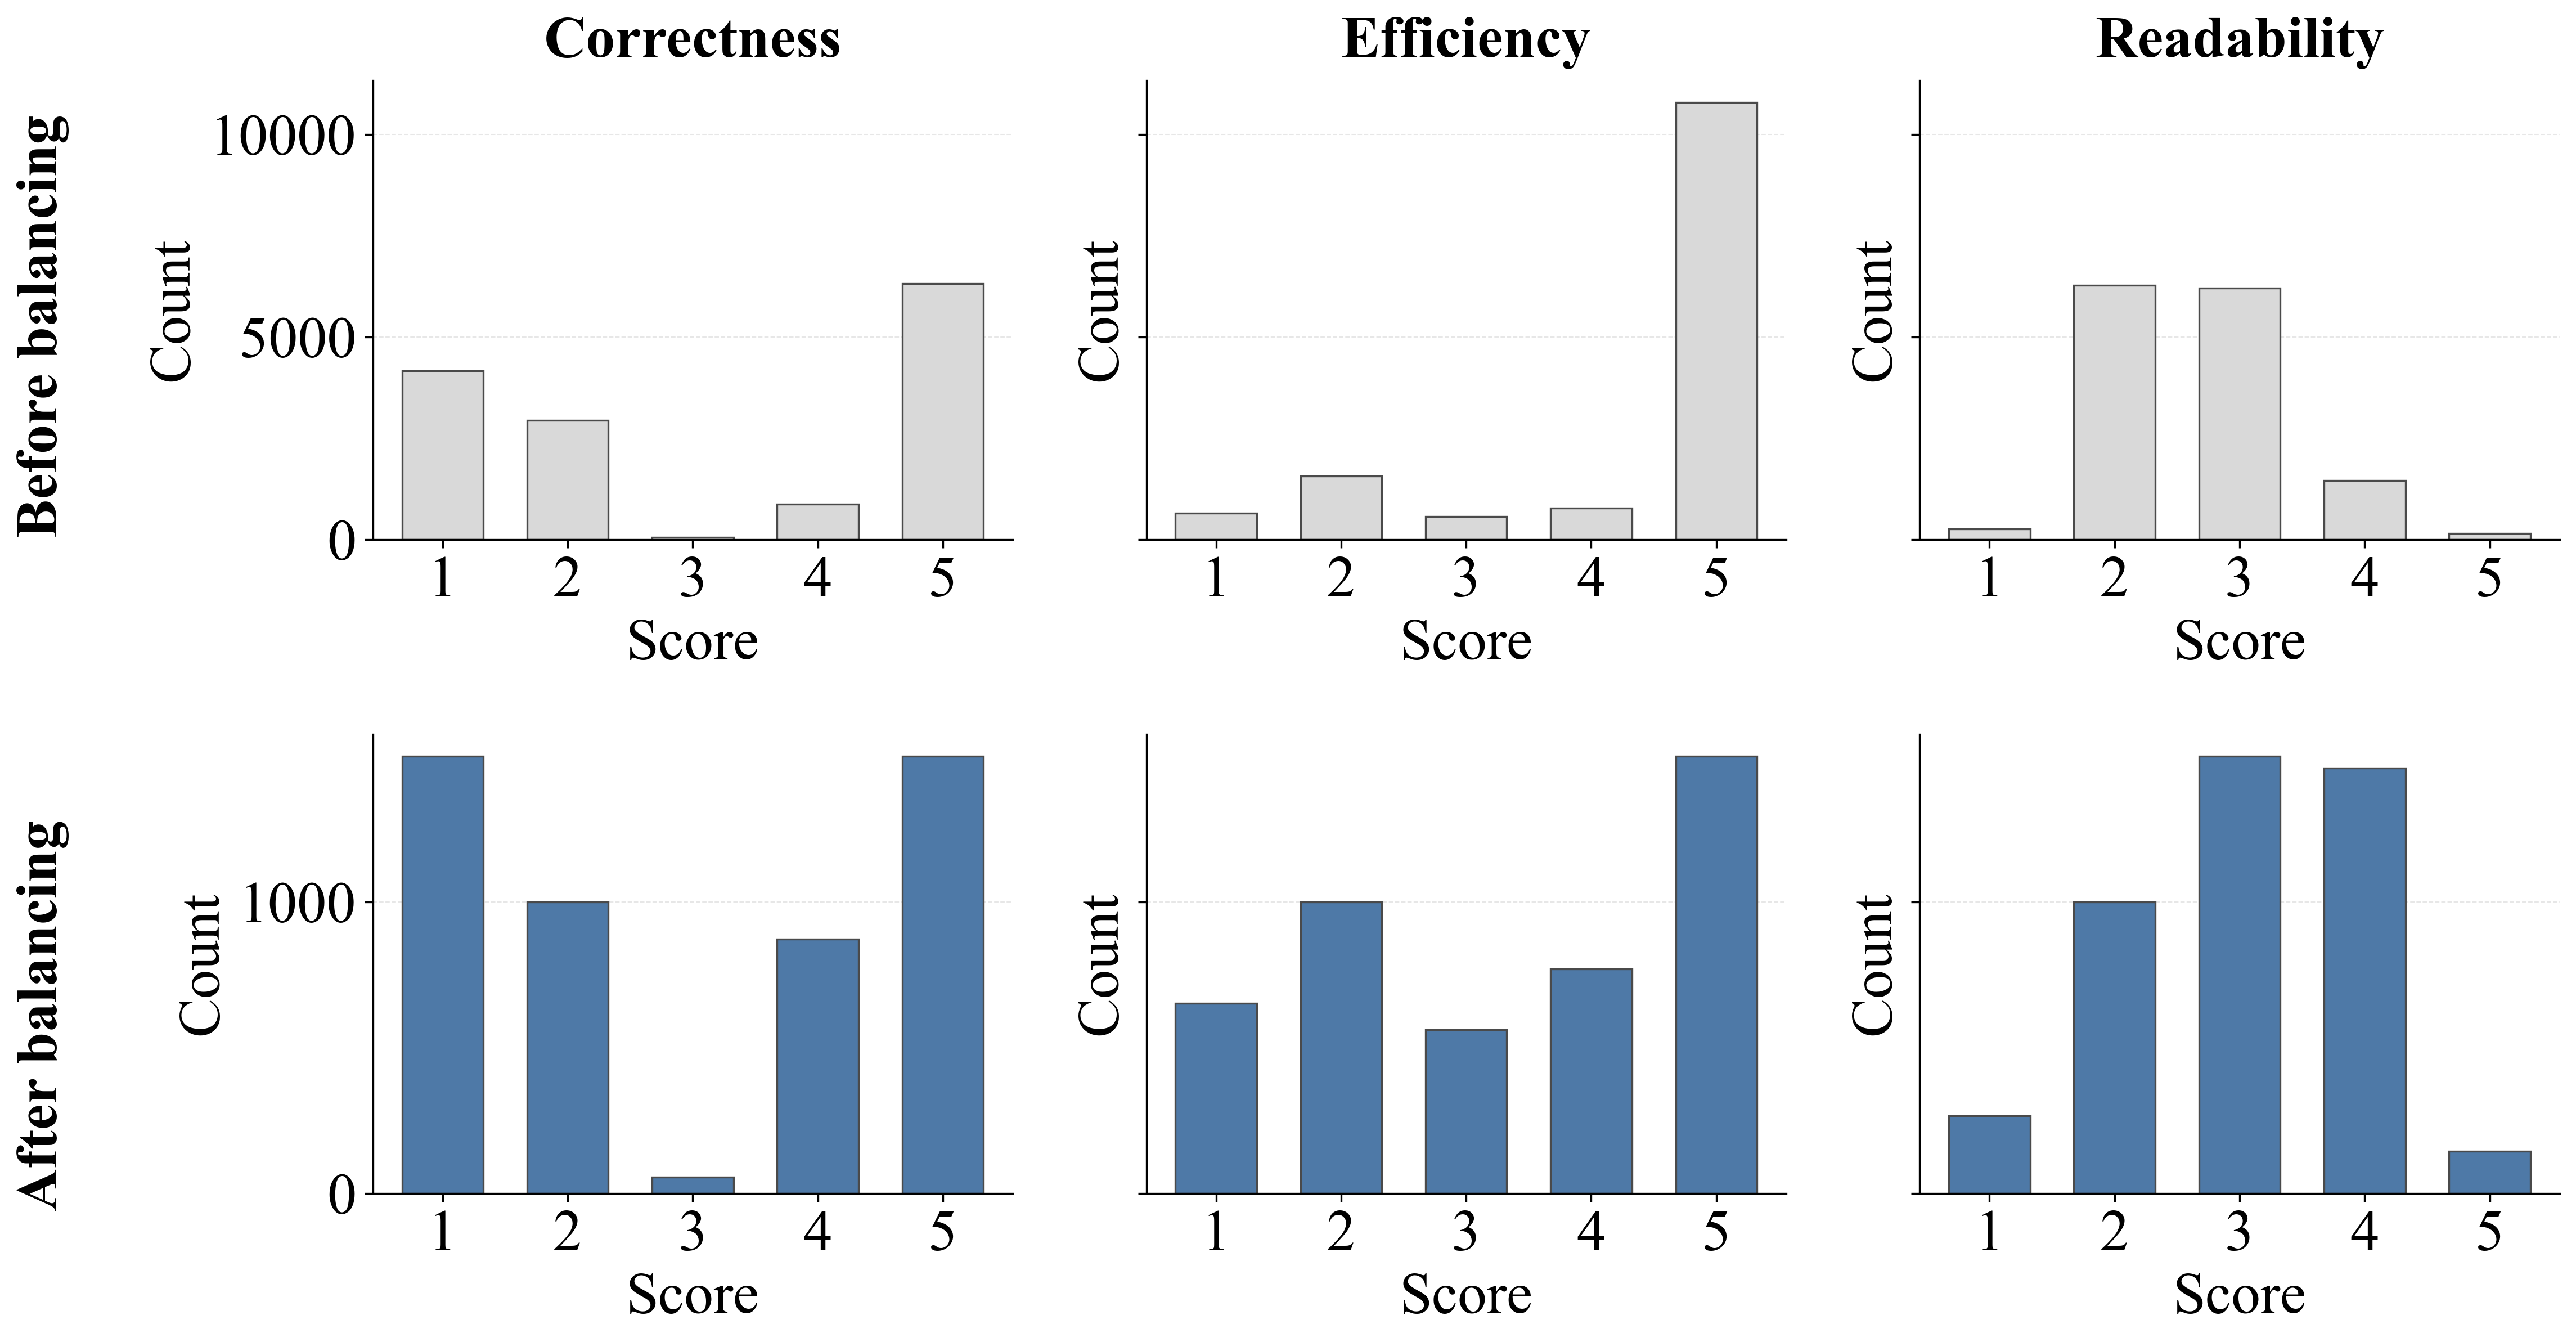

In [ ]:
plt.style.use("default")

plt.rcParams.update({
    "font.family": "Times New Roman",  
    "font.size": 25,
    "axes.titlesize": 25,
    "axes.labelsize": 25,
    "xtick.labelsize": 25,
    "ytick.labelsize": 25,
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "svg.fonttype": "path",
})

train_criteria = criteria.copy()

pair_criteria = sorted(expanded_df["criterion"].unique())

fig, axes = plt.subplots(
    2,
    3,
    figsize=(16, 8.5),
    sharey="row"
)

before_color = "#D9D9D9"
after_color = "#4E79A7"
edge_color = "#4A4A4A"

for ax, c in zip(axes[0], train_criteria):

    counts = train_df[c].value_counts().sort_index()

    ax.bar(
        counts.index.astype(str),
        counts.values,
        color=before_color,
        edgecolor=edge_color,
        linewidth=0.8,
        width=0.65,
    )

    ax.set_title(
        c.replace("gt_", "").replace("_score", "").capitalize(),
        fontweight="bold",
        pad=10
    )

    ax.set_xlabel("Score")
    ax.set_ylabel("Count")

    ax.grid(
        axis="y",
        linestyle="--",
        linewidth=0.5,
        alpha=0.3
    )

    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

for ax, c in zip(axes[1], pair_criteria):

    tmp = expanded_df[
        expanded_df["criterion"] == c
    ]

    counts = (
        tmp["score"]
        .value_counts()
        .sort_index()
    )

    ax.bar(
        counts.index.astype(str),
        counts.values,
        color=after_color,
        edgecolor=edge_color,
        linewidth=0.8,
        width=0.65,
    )

    ax.set_xlabel("Score")
    ax.set_ylabel("Count")

    ax.grid(
        axis="y",
        linestyle="--",
        linewidth=0.5,
        alpha=0.3
    )

    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.text(
    0.035,
    0.74,
    "Before balancing",
    fontsize=25,
    fontweight="bold",
    rotation=90,
    va="center"
)

fig.text(
    0.035,
    0.26,
    "After balancing",
    fontsize=25,
    fontweight="bold",
    rotation=90,
    va="center"
)

plt.tight_layout(rect=[0.06, 0, 1, 1])

plt.savefig(
    "pointwise_distribution_before_after.svg",
    format="svg",
    bbox_inches="tight"
)

plt.show()

In [185]:
expanded_df["criterion"].value_counts().rename_axis("criterion").reset_index(name="count")

,criterion,count
0,correctness,4928
1,efficiency,4485
2,readability,4371


## Pairwise

In [186]:
pairwise_path = DATA_DIR / "pairwise_train_labels.jsonl"
pairwise_balanced_path = DATA_DIR / "pairwise_train_labels_balanced.jsonl"

pairwise_df = load_jsonl(pairwise_path)
pairwise_balanced_df = load_jsonl(pairwise_balanced_path)

In [187]:
def summarize_pairwise(df, name):
    print("=" * 60)
    print(name)
    print("=" * 60)

    print(f"Samples        : {len(df)}")
    print(f"Unique id      : {df['id'].nunique()}")
    print(f"Unique pairs   : {len(df[['sub_id_1', 'sub_id_2']].drop_duplicates())}")
    print()

summarize_pairwise(pairwise_df, "Original Pairwise")
summarize_pairwise(pairwise_balanced_df, "Balanced Pairwise")

Original Pairwise
Samples        : 124350
Unique id      : 743
Unique pairs   : 88072

Balanced Pairwise
Samples        : 84821
Unique id      : 741
Unique pairs   : 74966



In [188]:
print("Original")
display(
    pairwise_df["criteria"]
    .value_counts()
    .rename_axis("criterion")
    .reset_index(name="count")
)

print("Balanced")
display(
    pairwise_balanced_df["criteria"]
    .value_counts()
    .rename_axis("criterion")
    .reset_index(name="count")
)

Original


,criterion,count
0,correctness,49749
1,efficiency,38187
2,readability,36414


Balanced


,criterion,count
0,efficiency,30865
1,readability,27385
2,correctness,26571


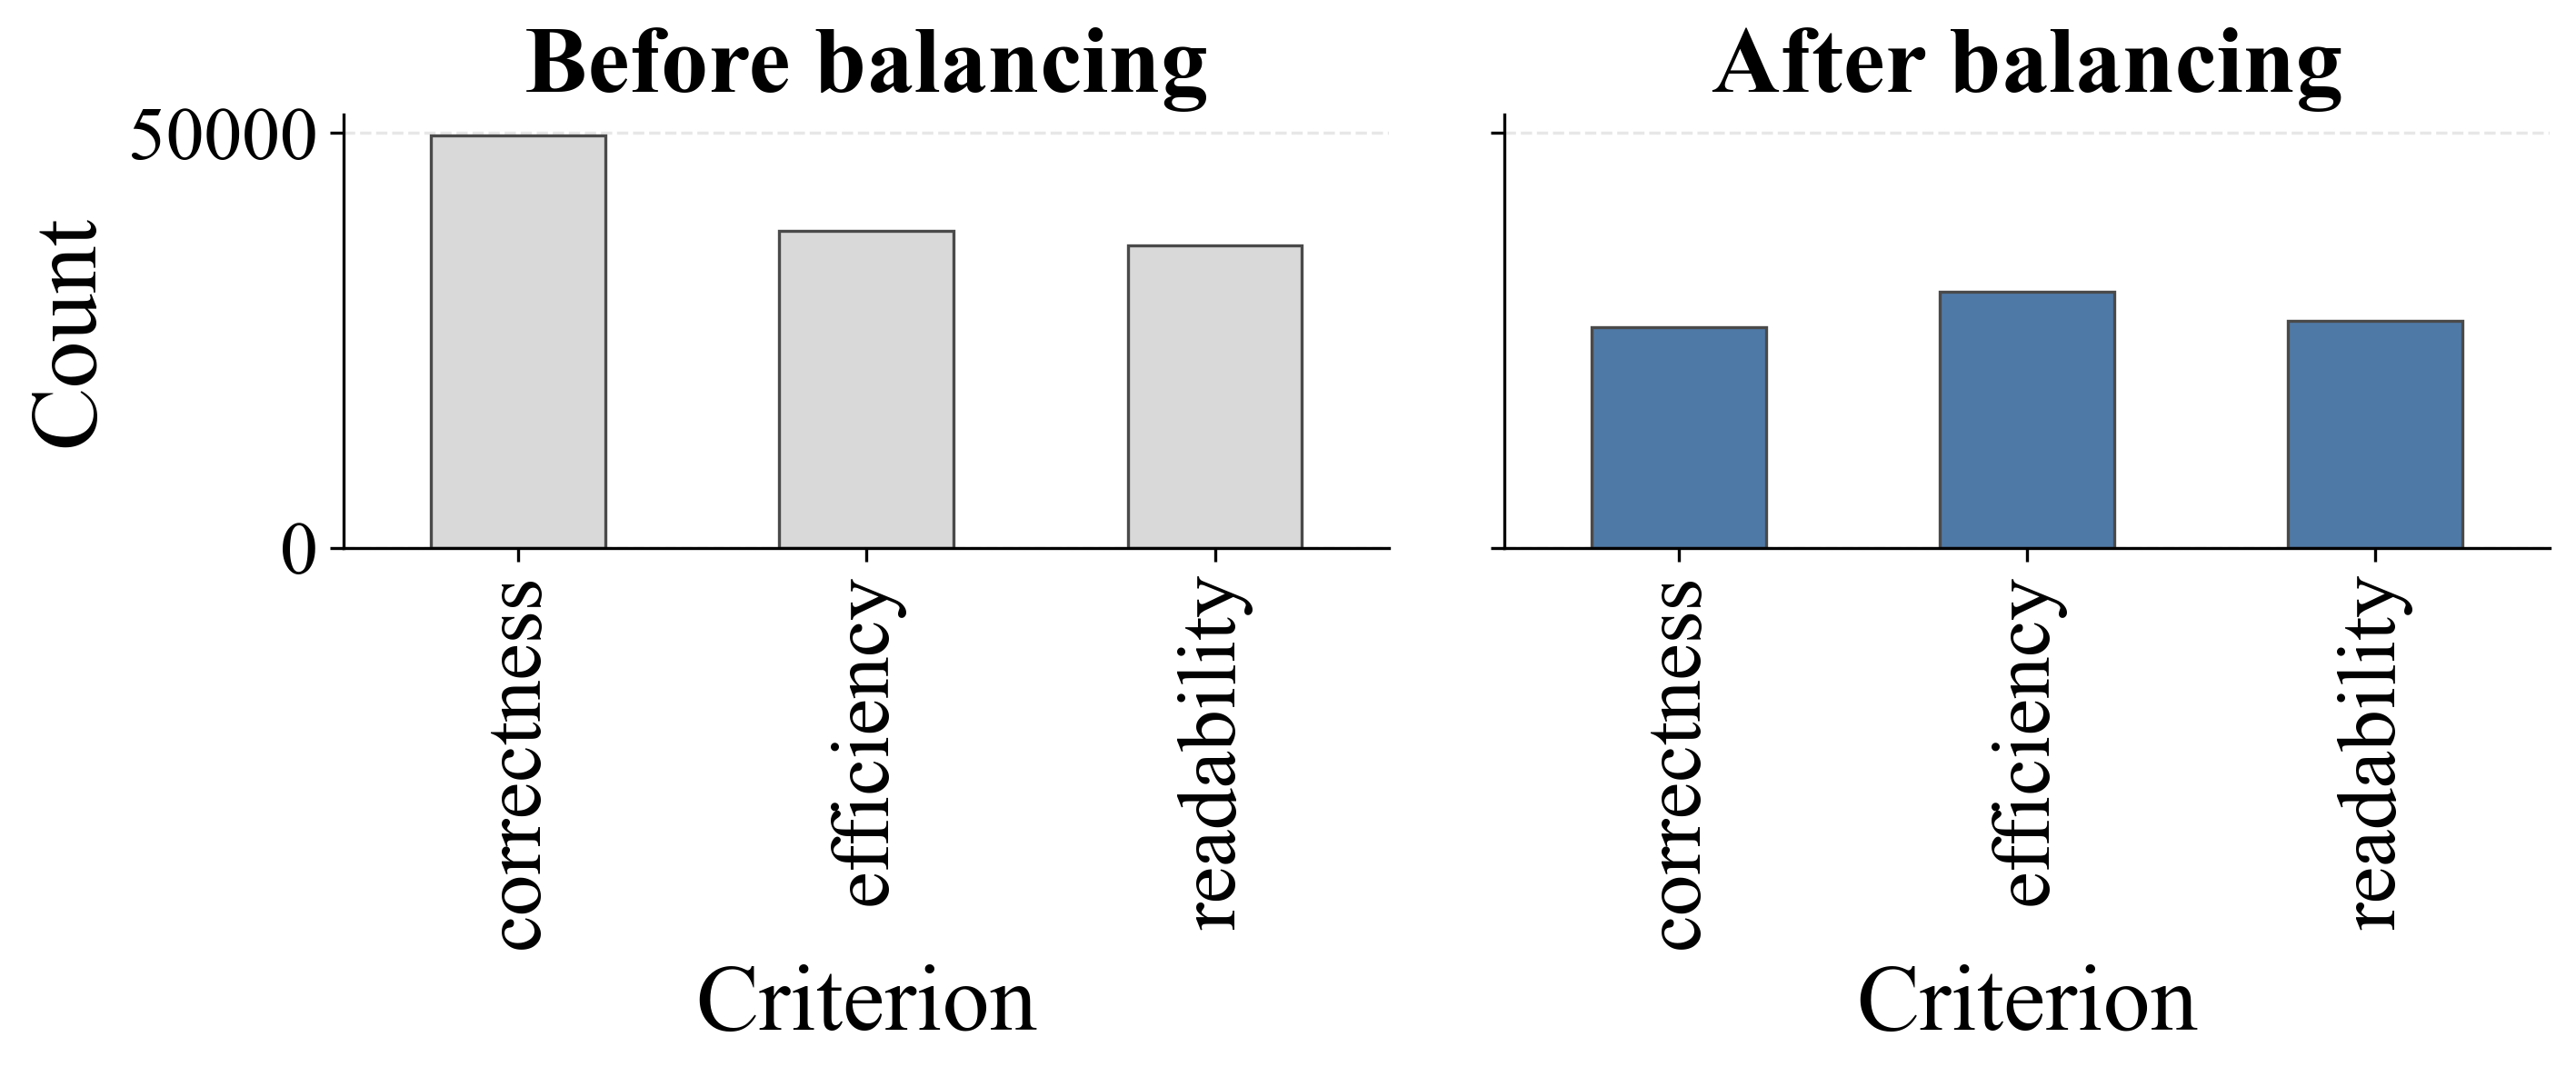

In [189]:
plt.style.use("default")

plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 25,
    "axes.titlesize": 25,
    "axes.labelsize": 25,
    "xtick.labelsize": 22,
    "ytick.labelsize": 20,
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "svg.fonttype": "path",
})

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharey=True)

before_color = "#D9D9D9"
after_color = "#4E79A7"
edge_color = "#4A4A4A"

pairwise_df["criteria"].value_counts().sort_index().plot(
    kind="bar",
    ax=axes[0],
    color=before_color,
    edgecolor=edge_color,
    linewidth=0.8,
)

axes[0].set_title("Before balancing", fontweight="bold")
axes[0].set_xlabel("Criterion")
axes[0].set_ylabel("Count")
axes[0].grid(axis="y", linestyle="--", alpha=0.3)
axes[0].set_axisbelow(True)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

pairwise_balanced_df["criteria"].value_counts().sort_index().plot(
    kind="bar",
    ax=axes[1],
    color=after_color,
    edgecolor=edge_color,
    linewidth=0.8,
)

axes[1].set_title("After balancing", fontweight="bold")
axes[1].set_xlabel("Criterion")
axes[1].set_ylabel("Count")
axes[1].grid(axis="y", linestyle="--", alpha=0.3)
axes[1].set_axisbelow(True)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "pairwise_criteria_distribution_before_after.svg",
    format="svg",
    bbox_inches="tight"
)

plt.show()

In [190]:
print("Original")
display(
    pairwise_df["label"]
    .value_counts()
    .sort_index()
)

print("Balanced")
display(
    pairwise_balanced_df["label"]
    .value_counts()
    .sort_index()
)

Original


label
0.0    28066
0.5    24821
1.0    71463
Name: count, dtype: int64

Balanced


label
0.0    30000
0.5    24821
1.0    30000
Name: count, dtype: int64

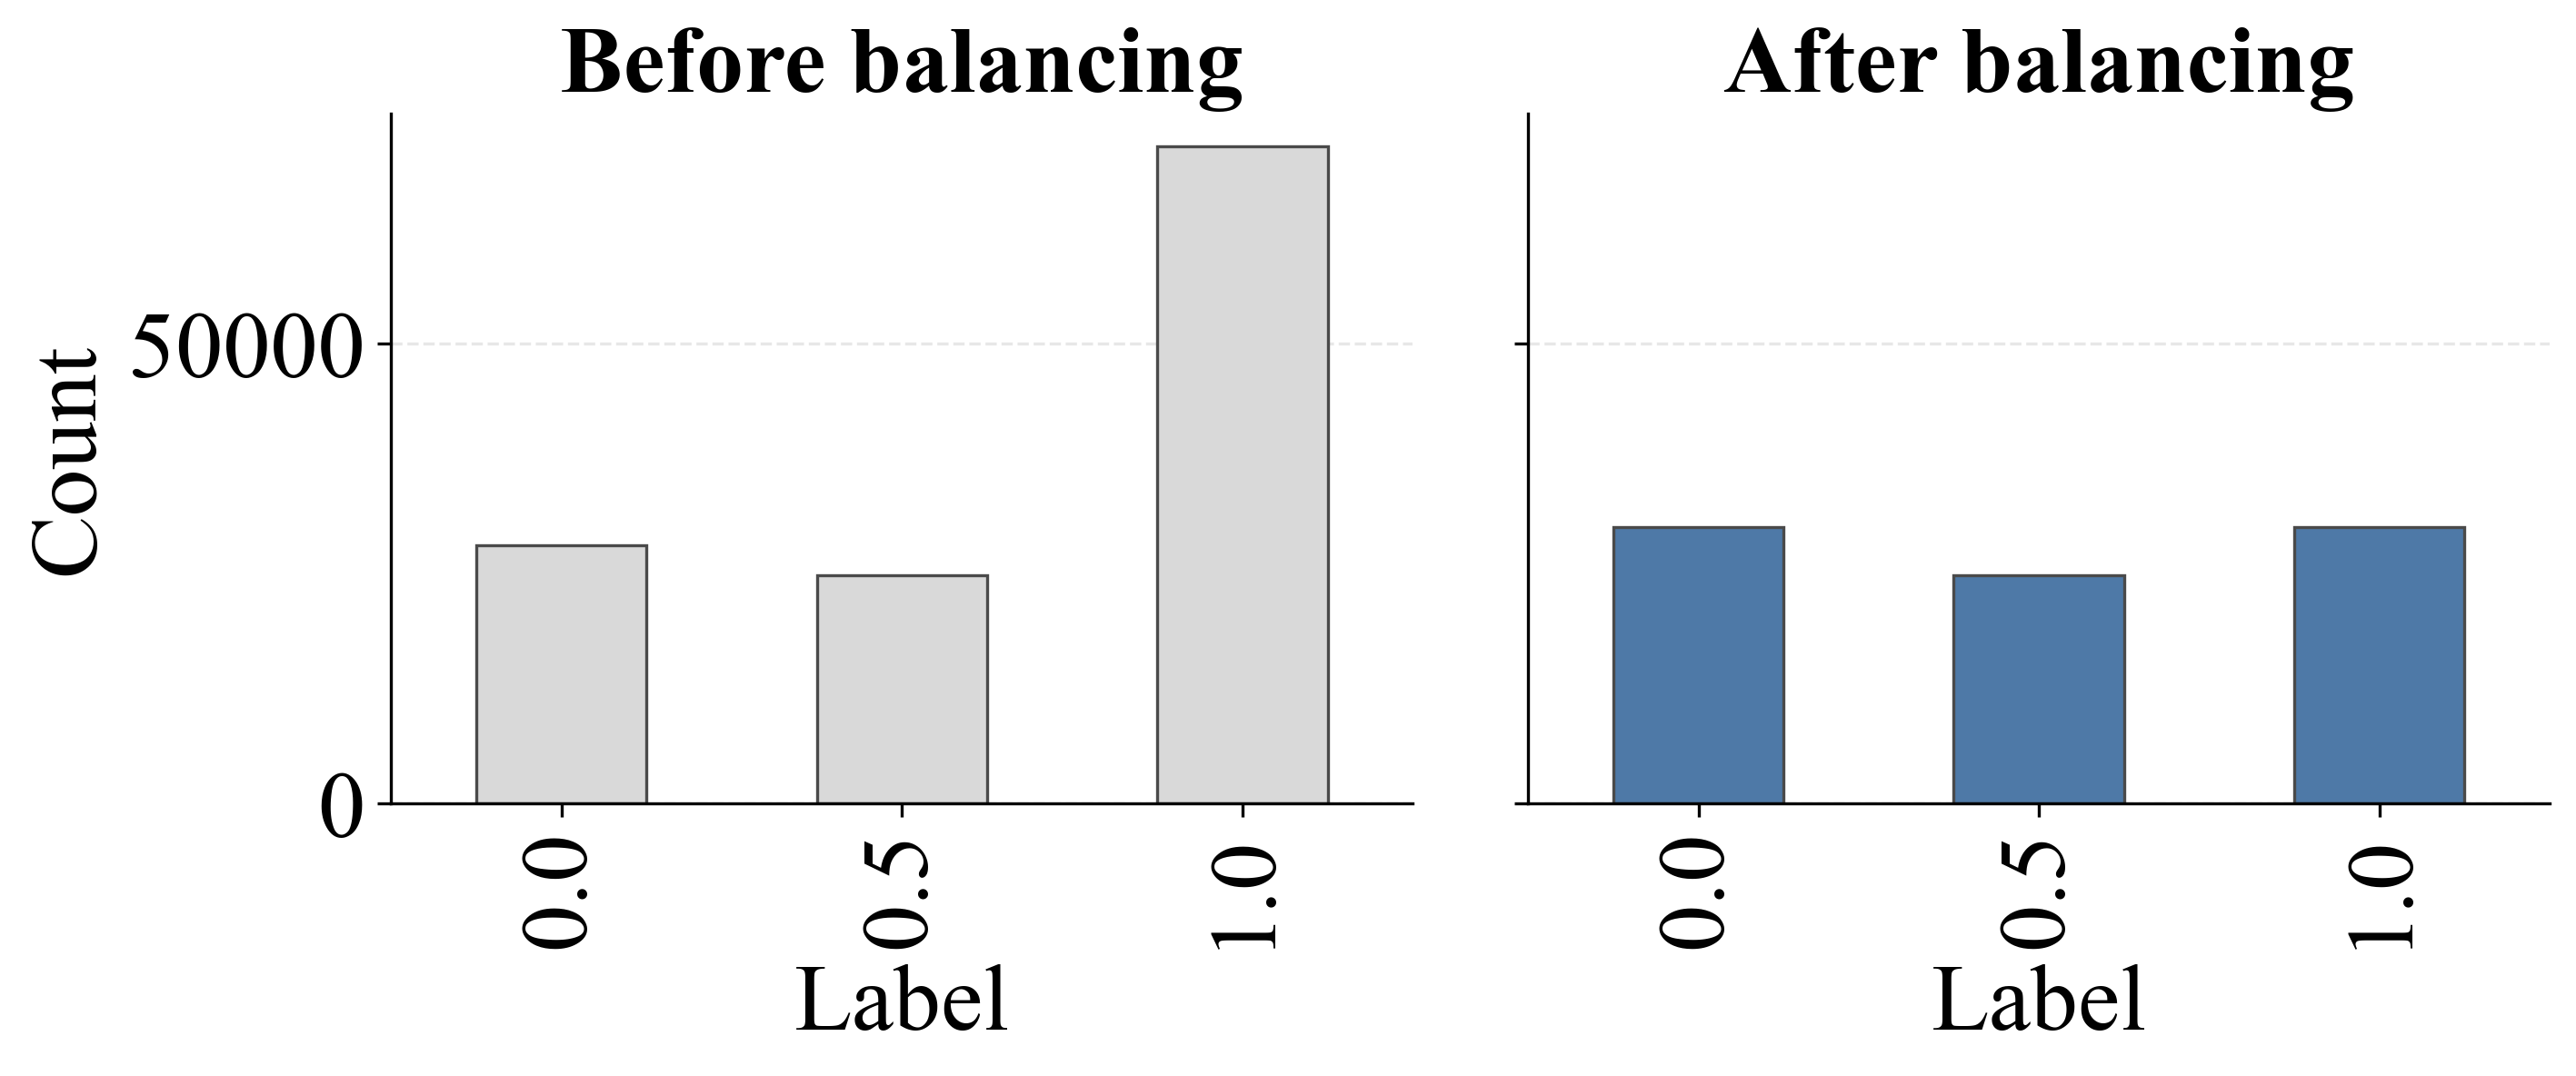

In [ ]:
plt.style.use("default")

plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 25,
    "axes.titlesize": 25,
    "axes.labelsize": 25,
    "xtick.labelsize": 25,
    "ytick.labelsize": 25,
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "svg.fonttype": "path",
})

before_color = "#D9D9D9"
after_color = "#4E79A7"
edge_color = "#4A4A4A"

fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 4.5),
    sharey=True
)

pairwise_df["label"].value_counts().sort_index().plot(
    kind="bar",
    ax=axes[0],
    color=before_color,
    edgecolor=edge_color,
    linewidth=0.8,
)

axes[0].set_title("Before balancing", fontweight="bold")
axes[0].set_xlabel("Label")
axes[0].set_ylabel("Count")
axes[0].grid(axis="y", linestyle="--", alpha=0.3)
axes[0].set_axisbelow(True)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

pairwise_balanced_df["label"].value_counts().sort_index().plot(
    kind="bar",
    ax=axes[1],
    color=after_color,
    edgecolor=edge_color,
    linewidth=0.8,
)

axes[1].set_title("After balancing", fontweight="bold")
axes[1].set_xlabel("Label")
axes[1].set_ylabel("Count")
axes[1].grid(axis="y", linestyle="--", alpha=0.3)
axes[1].set_axisbelow(True)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "pairwise_label_distribution_before_after.svg",
    format="svg",
    bbox_inches="tight"
)

plt.show()

In [192]:
def pairwise_distribution(df):
    return (
        df.groupby(["criteria", "label"])
        .size()
        .unstack(fill_value=0)
        .sort_index(axis=1)
    )

print("Original")
display(pairwise_distribution(pairwise_df))

print("Balanced")
display(pairwise_distribution(pairwise_balanced_df))

Original


label,0.0,0.5,1.0
criteria,,,
correctness,10748,6571,32430
efficiency,7783,10865,19539
readability,9535,7385,19494


Balanced


label,0.0,0.5,1.0
criteria,,,
correctness,10000,6571,10000
efficiency,10000,10865,10000
readability,10000,7385,10000


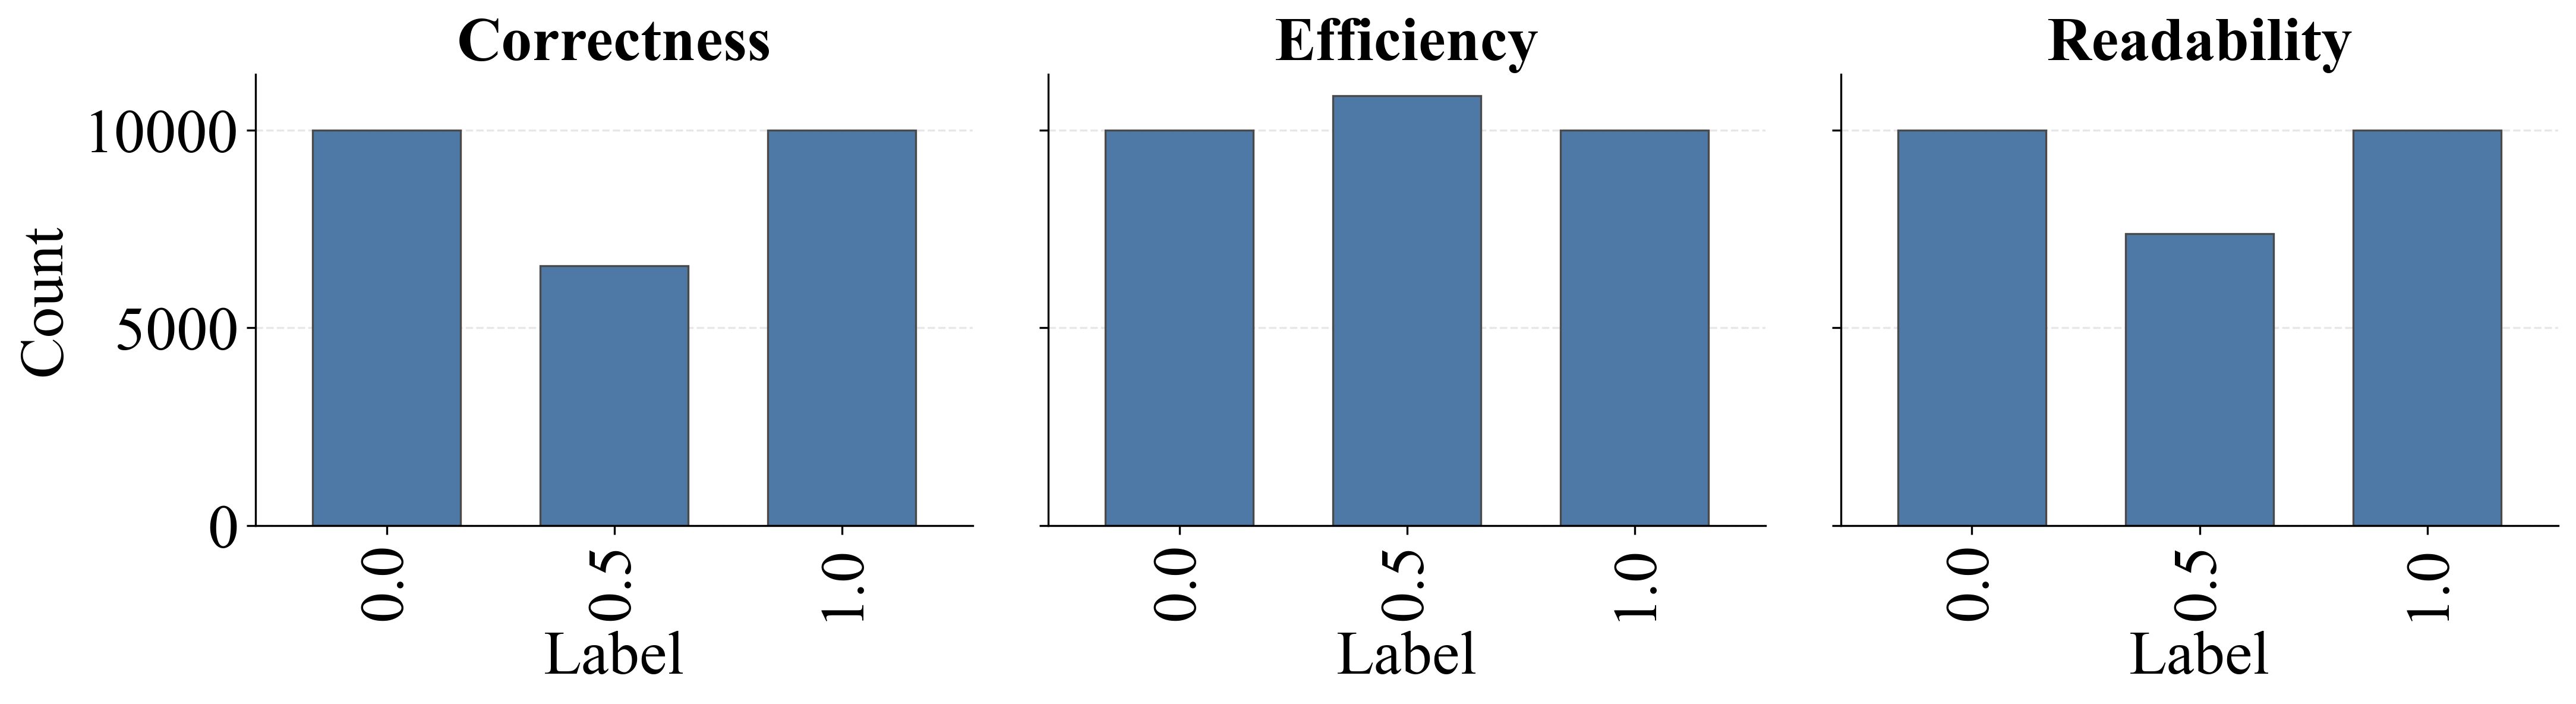

In [193]:
plt.style.use("default")

plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 25,
    "axes.titlesize": 25,
    "axes.labelsize": 25,
    "xtick.labelsize": 25,
    "ytick.labelsize": 25,
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "svg.fonttype": "path",
})

criteria = sorted(pairwise_balanced_df["criteria"].unique())

fig, axes = plt.subplots(
    1,
    len(criteria),
    figsize=(15, 4.5),
    sharey=True
)

if len(criteria) == 1:
    axes = [axes]

bar_color = "#4E79A7"
edge_color = "#4A4A4A"

for ax, c in zip(axes, criteria):

    counts = (
        pairwise_balanced_df[
            pairwise_balanced_df["criteria"] == c
        ]["label"]
        .value_counts()
        .sort_index()
    )

    counts.plot(
        kind="bar",
        ax=ax,
        color=bar_color,
        edgecolor=edge_color,
        linewidth=0.8,
        width=0.65,
    )

    ax.set_title(
        c.capitalize(),
        fontweight="bold"
    )

    ax.set_xlabel("Label")
    ax.set_ylabel("Count")

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.3
    )

    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "pairwise_label_distribution_by_criterion.svg",
    format="svg",
    bbox_inches="tight"
)

plt.show()